In [2]:
!pip install --upgrade pip
!pip install fvcore iopath matplotlib ninja
!MAX_JOBS=1 pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation --no-cache-dir

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Cloning https://gitee.com/hongwenzhang/pytorch3d.git to /tmp/pip-req-build-prhd_rxi
  Running command git clone --filter=blob:none --quiet https://gitee.com/hongwenzhang/pytorch3d.git /tmp/pip-req-build-prhd_rxi
  Resolved https://gitee.com/hongwenzhang/pytorch3d.git to commit b6a77ad7aaf41ed90fca80ce6a2bac3c462a7881
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pytorch3d: filename=pytorch3d-0.7.9-cp311-cp311-linux_x86_64.whl size=64484698 sha256=82a1c771c58c3b8bef8ed62c2e93f63689880dcbd2420b73a40246f7749fc13d
  Stored in directory: /tmp/pip-ephem-wheel-cache-usyoaz6i/wheels/2d/8b/12/6e318153711ff74bb8bc1b6ef9e1f7fb0efd88402eace988f3
Successfully built pytorch3d


In [3]:
import torch
import pytorch3d

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("pytorch3d:", pytorch3d.__version__)

torch: 2.9.1+cu128
cuda: True
pytorch3d: 0.7.9


迭代步数: 299/300 | 总 Loss: 0.0179 | 剪影误差: 0.0141
[*] 已保存当前 3D 模型至: output_meshes/mesh_epoch_299.obj


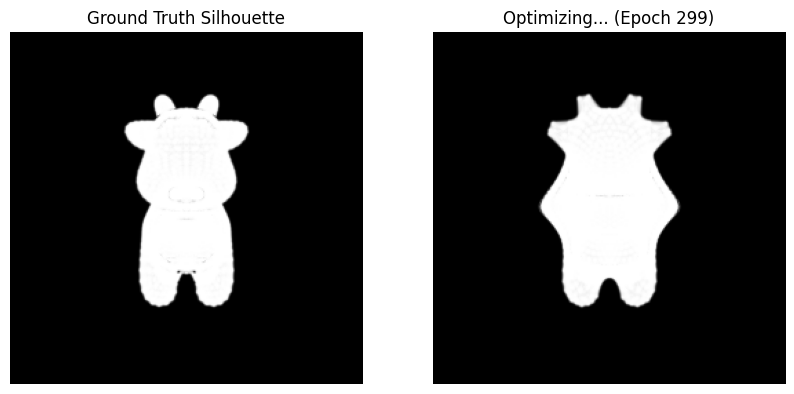

优化完成！所有中间状态的 .obj 文件已保存在 output_meshes 文件夹中。


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# ---------------------------------------------------------
# 1. 直接读取助教打包好的本地模型文件
# ---------------------------------------------------------
obj_path = "cow.obj" 
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0]) 
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# ---------------------------------------------------------
# 2. 渲染管线与摄像机配置
# ---------------------------------------------------------
num_views = 20
cameras = FoVPerspectiveCameras(device=device, 
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0], 
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras, 
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# ---------------------------------------------------------
# 3. 优化器初始化：从圆球开始
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# ---------------------------------------------------------
# 4. 可微渲染优化循环
# ---------------------------------------------------------
epochs = 300
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]
    
    # 【核心损失】：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           0.1 * mesh_edge_loss(new_src_mesh) + \
           0.01 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")
        
        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个（也是唯一一个）网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")
        
        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")

当前运行设备: cuda:0
cow.obj 已存在，跳过下载。
cow.mtl 已存在，跳过下载。
cow_texture.png 已存在，跳过下载。
带真实纹理的目标 cow mesh 加载完成。
多视角目标 RGB 图像和剪影图像生成完成。
开始优化：灰色球体 -> 彩色奶牛
Iter 0050/2000 | Total: 0.187714 | RGB: 0.078545 | Sil: 0.098506
Iter 0100/2000 | Total: 0.123410 | RGB: 0.055459 | Sil: 0.058426
Iter 0150/2000 | Total: 0.075568 | RGB: 0.039610 | Sil: 0.026896
Iter 0200/2000 | Total: 0.078439 | RGB: 0.038569 | Sil: 0.030867
Iter 0250/2000 | Total: 0.064478 | RGB: 0.031963 | Sil: 0.023568
Iter 0300/2000 | Total: 0.043035 | RGB: 0.026604 | Sil: 0.007641
Iter 0350/2000 | Total: 0.036224 | RGB: 0.023808 | Sil: 0.003446
Iter 0400/2000 | Total: 0.033771 | RGB: 0.022024 | Sil: 0.002987
Iter 0450/2000 | Total: 0.035274 | RGB: 0.020684 | Sil: 0.005955
Iter 0500/2000 | Total: 0.036895 | RGB: 0.023335 | Sil: 0.005037
Iter 0550/2000 | Total: 0.034246 | RGB: 0.021419 | Sil: 0.004570
Iter 0600/2000 | Total: 0.033622 | RGB: 0.019375 | Sil: 0.005695
Iter 0650/2000 | Total: 0.033457 | RGB: 0.020829 | Sil: 0.003708
Iter 0700/200

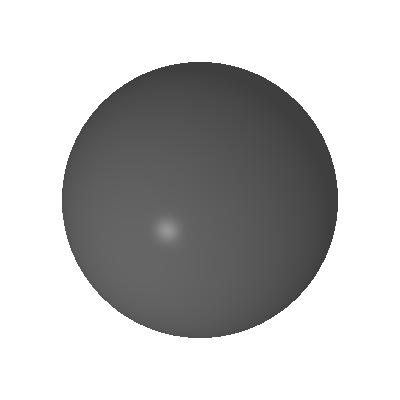

In [13]:
import os
import shutil
import urllib.request
import torch
import numpy as np
from PIL import Image as PILImage
from IPython.display import Image as IPyImage, display

from pytorch3d.utils import ico_sphere
from pytorch3d.io import load_objs_as_meshes, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    PointLights,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    SoftSilhouetteShader,
    TexturesVertex,
    BlendParams,
)

# =========================================================
# 选作：严格参考 PyTorch3D 官方 fit_textured_mesh 流程
#
# 目标：
# 从灰色球体出发，同时优化：
# 1. deform_verts：球体顶点偏移量，使形状接近 cow
# 2. sphere_verts_rgb：球体顶点颜色，使 RGB 渲染图接近带真实纹理的 cow
#
# 最终输出：
# cow_deform.gif
# final_model.obj
# final_colored_model.ply
# =========================================================

# ---------------------------------------------------------
# 0. 基础设置
# ---------------------------------------------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("当前运行设备:", device)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 为了复现实验结果，固定随机种子
torch.manual_seed(0)
np.random.seed(0)

# ---------------------------------------------------------
# 1. 下载官方 cow.obj + cow.mtl + cow_texture.png
#    这一步非常关键：参考资料的彩色 cow 不是手工涂色，而是真实 texture
# ---------------------------------------------------------
DATA_DIR = "./data/cow_mesh"
os.makedirs(DATA_DIR, exist_ok=True)

files = {
    "cow.obj": "https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.obj",
    "cow.mtl": "https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.mtl",
    "cow_texture.png": "https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow_texture.png",
}

for filename, url in files.items():
    save_path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(save_path):
        print(f"正在下载 {filename} ...")
        urllib.request.urlretrieve(url, save_path)
    else:
        print(f"{filename} 已存在，跳过下载。")

obj_filename = os.path.join(DATA_DIR, "cow.obj")

# ---------------------------------------------------------
# 2. 读取带真实纹理的目标 cow mesh
# ---------------------------------------------------------
target_mesh = load_objs_as_meshes([obj_filename], device=device)

# 归一化：中心移到原点，缩放到单位范围
verts = target_mesh.verts_packed()
center = verts.mean(0)
scale = max((verts - center).abs().max(0)[0])

target_mesh.offset_verts_(-center)
target_mesh.scale_verts_(1.0 / float(scale))

print("带真实纹理的目标 cow mesh 加载完成。")

# ---------------------------------------------------------
# 3. 构造多视角目标数据：RGB 图像 + 剪影图像
# ---------------------------------------------------------
num_views = 20
image_size = 128

elev = torch.linspace(0, 360, num_views, device=device)
azim = torch.linspace(-180, 180, num_views, device=device)

lights = PointLights(
    device=device,
    location=[[0.0, 0.0, -3.0]],
)

R, T = look_at_view_transform(
    dist=2.7,
    elev=elev,
    azim=azim,
)

cameras = FoVPerspectiveCameras(
    device=device,
    R=R,
    T=T,
)

# 用于展示 GIF 的固定视角，和官方教程一致，取第 1 个视角
display_camera = FoVPerspectiveCameras(
    device=device,
    R=R[None, 1, ...],
    T=T[None, 1, ...],
)

target_cameras = [
    FoVPerspectiveCameras(
        device=device,
        R=R[None, i, ...],
        T=T[None, i, ...],
    )
    for i in range(num_views)
]

# RGB renderer：用于生成目标 RGB 图像
raster_settings_rgb = RasterizationSettings(
    image_size=image_size,
    blur_radius=0.0,
    faces_per_pixel=1,
)

renderer_rgb = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=display_camera,
        raster_settings=raster_settings_rgb,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=display_camera,
        lights=lights,
    ),
)

target_images = renderer_rgb(
    target_mesh.extend(num_views),
    cameras=cameras,
    lights=lights,
)

target_rgb = [
    target_images[i, ..., :3].detach()
    for i in range(num_views)
]

# Soft silhouette renderer：用于生成目标剪影图像
sigma = 1e-4
raster_settings_silhouette = RasterizationSettings(
    image_size=image_size,
    blur_radius=np.log(1.0 / 1e-4 - 1.0) * sigma,
    faces_per_pixel=50,
)

renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=display_camera,
        raster_settings=raster_settings_silhouette,
    ),
    shader=SoftSilhouetteShader(),
)

silhouette_images = renderer_silhouette(
    target_mesh.extend(num_views),
    cameras=cameras,
    lights=lights,
)

target_silhouette = [
    silhouette_images[i, ..., 3].detach()
    for i in range(num_views)
]

print("多视角目标 RGB 图像和剪影图像生成完成。")

# ---------------------------------------------------------
# 4. 初始化源模型：灰色球体
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)

verts_shape = src_mesh.verts_packed().shape

# 形状参数：学习每个顶点的偏移量
deform_verts = torch.full(
    verts_shape,
    0.0,
    device=device,
    requires_grad=True,
)

# 颜色参数：学习每个顶点的 RGB 颜色
# 初始值为 0.5，即灰色球体
sphere_verts_rgb = torch.full(
    [1, verts_shape[0], 3],
    0.5,
    device=device,
    requires_grad=True,
)

# ---------------------------------------------------------
# 5. 构造可微 RGB renderer
#    参考教程中选作用 SoftPhongShader，而不是 SoftSilhouetteShader
# ---------------------------------------------------------
raster_settings_soft = RasterizationSettings(
    image_size=image_size,
    blur_radius=np.log(1.0 / 1e-4 - 1.0) * sigma,
    faces_per_pixel=50,
    perspective_correct=False,
)

renderer_textured = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=display_camera,
        raster_settings=raster_settings_soft,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=display_camera,
        lights=lights,
    ),
)

# ---------------------------------------------------------
# 6. 损失函数设置
# ---------------------------------------------------------
loss_weights = {
    "rgb": 1.0,
    "silhouette": 1.0,
    "edge": 1.0,
    "normal": 0.01,
    "laplacian": 1.0,
}

def update_mesh_shape_prior_losses(mesh, loss_dict):
    loss_dict["edge"] = mesh_edge_loss(mesh)
    loss_dict["normal"] = mesh_normal_consistency(mesh)
    loss_dict["laplacian"] = mesh_laplacian_smoothing(mesh, method="uniform")

# 参考教程使用 SGD
optimizer = torch.optim.SGD(
    [deform_verts, sphere_verts_rgb],
    lr=1.0,
    momentum=0.9,
)

# ---------------------------------------------------------
# 7. GIF 渲染函数
# ---------------------------------------------------------
gif_size = 400

raster_settings_gif = RasterizationSettings(
    image_size=gif_size,
    blur_radius=0.0,
    faces_per_pixel=1,
)

# 这里用白色背景，光照更接近参考效果
gif_lights = PointLights(
    device=device,
    location=[[0.0, 0.0, -3.0]],
)

gif_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=display_camera,
        raster_settings=raster_settings_gif,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=display_camera,
        lights=gif_lights,
        blend_params=BlendParams(background_color=(1.0, 1.0, 1.0)),
    ),
)

def render_mesh_to_pil(mesh):
    with torch.no_grad():
        image = gif_renderer(
            mesh,
            cameras=display_camera,
            lights=gif_lights,
        )
    rgb = image[0, ..., :3].detach().cpu().clamp(0.0, 1.0).numpy()
    rgb = (rgb * 255).astype(np.uint8)
    return PILImage.fromarray(rgb)

def get_current_mesh():
    current_mesh = src_mesh.offset_verts(deform_verts)
    current_colors = sphere_verts_rgb.clamp(0.0, 1.0)
    current_mesh.textures = TexturesVertex(verts_features=current_colors)
    return current_mesh

# ---------------------------------------------------------
# 8. 优化：同时拟合 RGB + silhouette + 正则化
# ---------------------------------------------------------
Niter = 2000
num_views_per_iteration = 2
gif_period = 100

gif_frames = []

# 第 0 帧：灰色球体
with torch.no_grad():
    gif_frames.append(render_mesh_to_pil(get_current_mesh()))

print("开始优化：灰色球体 -> 彩色奶牛")

for i in range(Niter):
    optimizer.zero_grad()

    new_src_mesh = get_current_mesh()

    loss = {
        "rgb": torch.tensor(0.0, device=device),
        "silhouette": torch.tensor(0.0, device=device),
        "edge": torch.tensor(0.0, device=device),
        "normal": torch.tensor(0.0, device=device),
        "laplacian": torch.tensor(0.0, device=device),
    }

    update_mesh_shape_prior_losses(new_src_mesh, loss)

    # 每轮随机选两个视角，和参考教程一致
    selected_views = np.random.permutation(num_views).tolist()[:num_views_per_iteration]

    for j in selected_views:
        images_predicted = renderer_textured(
            new_src_mesh,
            cameras=target_cameras[j],
            lights=lights,
        )

        predicted_silhouette = images_predicted[..., 3]
        predicted_rgb = images_predicted[..., :3]

        loss_silhouette = ((predicted_silhouette - target_silhouette[j]) ** 2).mean()
        loss_rgb = ((predicted_rgb - target_rgb[j]) ** 2).mean()

        loss["silhouette"] += loss_silhouette / num_views_per_iteration
        loss["rgb"] += loss_rgb / num_views_per_iteration

    sum_loss = torch.tensor(0.0, device=device)
    for k in loss:
        sum_loss = sum_loss + loss[k] * loss_weights[k]

    sum_loss.backward()
    optimizer.step()

    # 限制顶点颜色在 [0, 1]，防止颜色爆掉
    with torch.no_grad():
        sphere_verts_rgb.clamp_(0.0, 1.0)

    if (i + 1) % 50 == 0:
        print(
            f"Iter {i+1:04d}/{Niter} | "
            f"Total: {sum_loss.item():.6f} | "
            f"RGB: {loss['rgb'].item():.6f} | "
            f"Sil: {loss['silhouette'].item():.6f}"
        )

    if (i + 1) % gif_period == 0 or i == Niter - 1:
        with torch.no_grad():
            gif_frames.append(render_mesh_to_pil(get_current_mesh()))

# 最后一帧停留更久
for _ in range(8):
    gif_frames.append(gif_frames[-1])

print("优化完成，开始保存结果。")

# ---------------------------------------------------------
# 9. 保存 GIF、OBJ、PLY
# ---------------------------------------------------------
output_dir = "output_textured_fit_official"
os.makedirs(output_dir, exist_ok=True)

final_mesh = get_current_mesh()
final_verts, final_faces = final_mesh.get_mesh_verts_faces(0)

# 注意：这个 final_verts 是归一化空间下的结果，适合和 GIF 对应
final_obj_path = os.path.join(output_dir, "final_model.obj")
save_obj(final_obj_path, final_verts, final_faces)

def save_colored_ply(path, verts_tensor, faces_tensor, colors_tensor):
    verts_np = verts_tensor.detach().cpu().numpy()
    faces_np = faces_tensor.detach().cpu().numpy()
    colors_np = (
        colors_tensor.detach().cpu().clamp(0, 1).numpy() * 255
    ).astype(np.uint8)

    # colors_tensor shape: [1, V, 3]
    if colors_np.ndim == 3:
        colors_np = colors_np[0]

    with open(path, "w") as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {verts_np.shape[0]}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write(f"element face {faces_np.shape[0]}\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")

        for v, c in zip(verts_np, colors_np):
            f.write(f"{v[0]} {v[1]} {v[2]} {c[0]} {c[1]} {c[2]}\n")

        for face in faces_np:
            f.write(f"3 {int(face[0])} {int(face[1])} {int(face[2])}\n")

final_ply_path = os.path.join(output_dir, "final_colored_model.ply")
save_colored_ply(
    final_ply_path,
    final_verts,
    final_faces,
    sphere_verts_rgb,
)

gif_path = "cow_deform.gif"
if os.path.exists(gif_path):
    os.remove(gif_path)

gif_frames[0].save(
    gif_path,
    save_all=True,
    append_images=gif_frames[1:],
    duration=180,
    loop=0,
)

shutil.copy(gif_path, os.path.join(output_dir, "cow_deform.gif"))

zip_name = "output_textured_fit_official"
zip_path = f"{zip_name}.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(zip_name, "zip", output_dir)

print("完成。生成文件：")
print(f"- {gif_path}")
print(f"- {final_obj_path}")
print(f"- {final_ply_path}")
print(f"- {zip_path}")

display(IPyImage(filename=gif_path))